# Lab Instructions

Choose your own adventure! In this lab, you will select a dataset, identify the target feature, and determine what relationships are present between the target and the other features in the data.

The dataset should have at least 5 features plus the target and at least a few hundred rows.  If the original dataset has more than 5 features, you may select the 5 that seem most interesting for this project. The subject can be anything you choose.  

For your lab submission, describe the dataset and the features - including all of the values of the features - and identify the target feature.  Then make visualizations to show the relationship of each feature to the target.  Which feature(s) seem most related?  Which features don't seem to influence the value of the target?  Draw at least one big picture conclusion about your data from the visualizations you've created.


For this lab I choose Sugarcane Production from Kaggle; https://www.kaggle.com/datasets/rajkumarpandey02/list-of-countries-by-sugarcane-production

The dataset contains information about sugarcane production for different countries around the world. Each row represents one country, and each column provides a different measurement related to sugarcane farming and output.

The 5 features are country, continent, production (Tons), Production per Person (Kg), Acreage (Hectare) and Yield (Kg / Hectare) with production being the target.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Load the dataset

df = pd.read_csv('Sugarcane.csv')


# 2. Clean numeric columns 

numeric_cols = [
    "Production (Tons)",
    "Production per Person (Kg)",
    "Acreage (Hectare)",
    "Yield (Kg / Hectare)"
]

for col in numeric_cols:
    # Remove dots used as thousand separators and commas used as decimal separators
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")

#print("\nAfter cleaning numeric columns:")
#print(df[numeric_cols].head())


# Drop rows with missing numeric values (if any)
df = df.dropna(subset=numeric_cols)

# 3. Set up plotting style

sns.set(style="whitegrid")





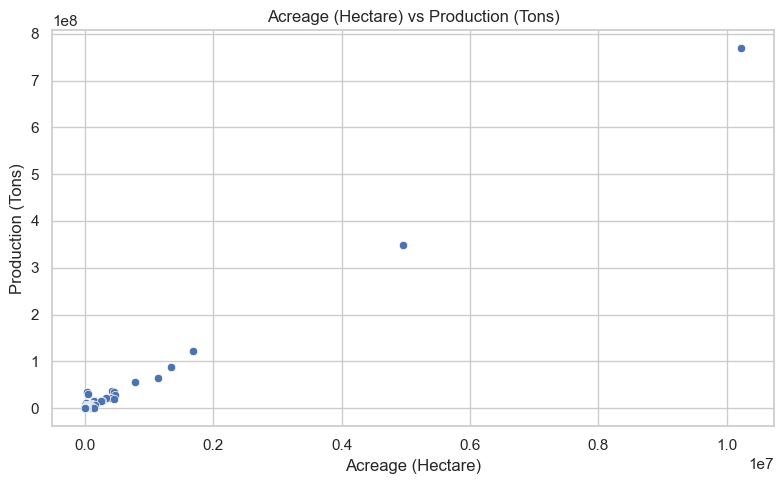

In [44]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Acreage (Hectare)",
    y="Production (Tons)"
)
plt.title("Acreage (Hectare) vs Production (Tons)")
plt.xlabel("Acreage (Hectare)")
plt.ylabel("Production (Tons)")
plt.tight_layout()
plt.show()


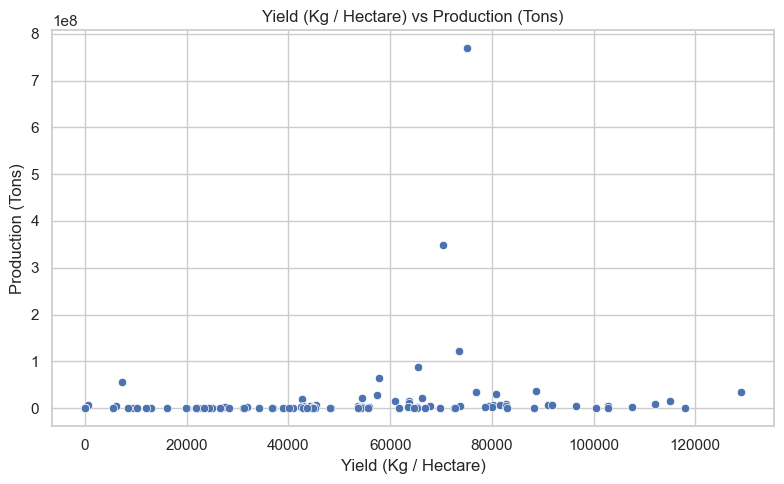

In [45]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Yield (Kg / Hectare)",
    y="Production (Tons)"
)
plt.title("Yield (Kg / Hectare) vs Production (Tons)")
plt.xlabel("Yield (Kg / Hectare)")
plt.ylabel("Production (Tons)")
plt.tight_layout()
plt.show()


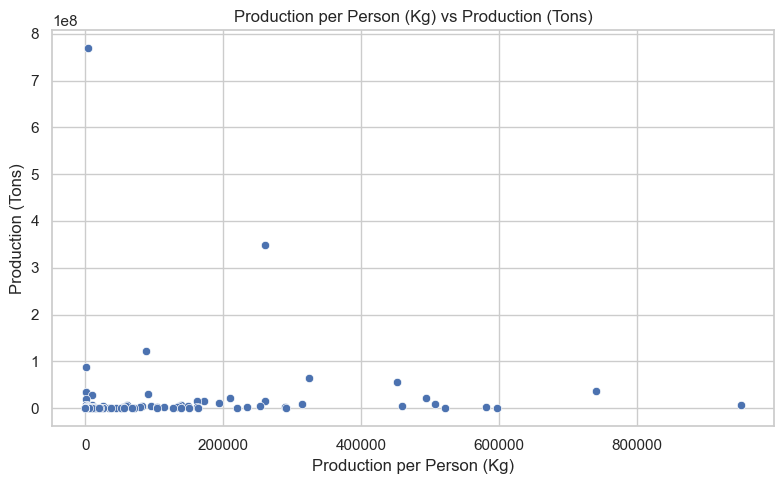

In [46]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Production per Person (Kg)",
    y="Production (Tons)"
)
plt.title("Production per Person (Kg) vs Production (Tons)")
plt.xlabel("Production per Person (Kg)")
plt.ylabel("Production (Tons)")
plt.tight_layout()
plt.show()


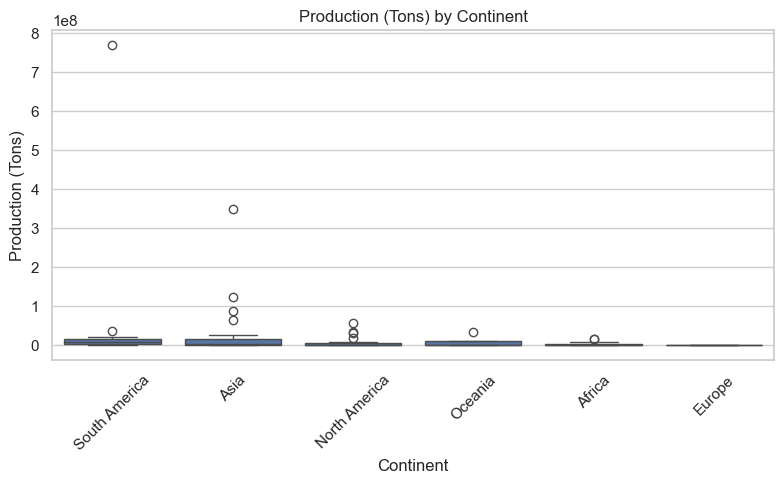

In [47]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="Continent",
    y="Production (Tons)"
)
plt.title("Production (Tons) by Continent")
plt.xlabel("Continent")
plt.ylabel("Production (Tons)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


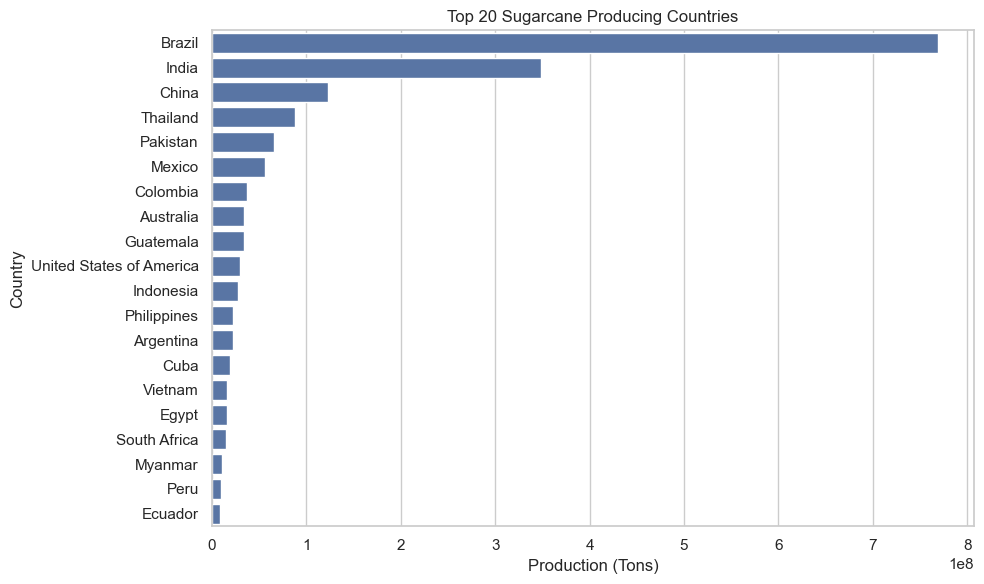

In [48]:
top20 = df.sort_values("Production (Tons)", ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top20,
    x="Production (Tons)",
    y="Country"
)
plt.title("Top 20 Sugarcane Producing Countries")
plt.xlabel("Production (Tons)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


Strong relationships to target
Acreage → Production More land = more sugarcane.

Yield → Production Higher yield = more efficient production.

Moderate relationship:
Year → Production
Some countries grow over time, others decline.

Weak relationships:
Continent → Production
Continent doesn’t necessarily cause production, but patterns may appear.

Useful for ranking, but not a numeric predictor.

In conclusion, the data shows that Sugarcane production is most strongly influenced by the acreage and the yield per hectare. Countries with both large agricultural areas and high yields produce the most sugarcane. Geographic continent and year show weaker relationships, suggesting that production is driven more by agricultural capacity than by location or time.



